# Zomato Restaurant Trend Analysis - Bangalore

## About The Project
This project is the detailed analysis of Zomato restaurant trend in bangalore. The goal is to generate insights about cost for two individuals, cuisines, rating and online order across restaurant in Bangalore.

## Dataset
Dataset sourced from kaggle, uploaded by Himanshu Poddar, containing 50K+ rows and 17 attributes of restaurant data scraped from Zomato's Bangalore listings.

## Tools Used:
- Language: Python
- Environment: Jupyter Notebook
- Data manipulation: pandas
- Visualisation: matplotlib, seaborn

## Key Questions to be Answered:
1. Which cuisines are most popular in Bangalore?
2. How are restaurant ratings distributed?
3. Does online ordering affect restaurant rating
4. Which area is the most competing for restaurant owners?
5. what is scenario of pricing for two persons?
6. Which restaurant type dominate the market?
7. Which restaurant type has the highest ratig?s?

## Analyst
Name: Adyasha Mantn
y
Date: 21st April 2026

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import os
print(os.getcwd())

C:\Users\abhij\OneDrive\Data Analytics\resume project\Zomato-trend-analysis\noteboooks


In [3]:
df = pd.read_csv(r'C:\Users\abhij\OneDrive\Data Analytics\resume project\Zomato-trend-analysis\Data\zomato.csv')

In [4]:
df.shape

(51717, 17)

In [5]:
df.columns.tolist()

['url',
 'address',
 'name',
 'online_order',
 'book_table',
 'rate',
 'votes',
 'phone',
 'location',
 'rest_type',
 'dish_liked',
 'cuisines',
 'approx_cost(for two people)',
 'reviews_list',
 'menu_item',
 'listed_in(type)',
 'listed_in(city)']

In [6]:
df.head(10)

,url,address,name,online_order,book_table,rate,votes,phone,location,rest_type,dish_liked,cuisines,approx_cost(for two people),reviews_list,menu_item,listed_in(type),listed_in(city)
0,https://www.zomato.com/bangalore/jalsa-banasha...,"942, 21st Main Road, 2nd Stage, Banashankari, ...",Jalsa,Yes,Yes,4.1/5,775,080 42297555\r\n+91 9743772233,Banashankari,Casual Dining,"Pasta, Lunch Buffet, Masala Papad, Paneer Laja...","North Indian, Mughlai, Chinese",800,"[('Rated 4.0', 'RATED\n A beautiful place to ...",[],Buffet,Banashankari
1,https://www.zomato.com/bangalore/spice-elephan...,"2nd Floor, 80 Feet Road, Near Big Bazaar, 6th ...",Spice Elephant,Yes,No,4.1/5,787,080 41714161,Banashankari,Casual Dining,"Momos, Lunch Buffet, Chocolate Nirvana, Thai G...","Chinese, North Indian, Thai",800,"[('Rated 4.0', 'RATED\n Had been here for din...",[],Buffet,Banashankari
2,https://www.zomato.com/SanchurroBangalore?cont...,"1112, Next to KIMS Medical College, 17th Cross...",San Churro Cafe,Yes,No,3.8/5,918,+91 9663487993,Banashankari,"Cafe, Casual Dining","Churros, Cannelloni, Minestrone Soup, Hot Choc...","Cafe, Mexican, Italian",800,"[('Rated 3.0', ""RATED\n Ambience is not that ...",[],Buffet,Banashankari
3,https://www.zomato.com/bangalore/addhuri-udupi...,"1st Floor, Annakuteera, 3rd Stage, Banashankar...",Addhuri Udupi Bhojana,No,No,3.7/5,88,+91 9620009302,Banashankari,Quick Bites,Masala Dosa,"South Indian, North Indian",300,"[('Rated 4.0', ""RATED\n Great food and proper...",[],Buffet,Banashankari
4,https://www.zomato.com/bangalore/grand-village...,"10, 3rd Floor, Lakshmi Associates, Gandhi Baza...",Grand Village,No,No,3.8/5,166,+91 8026612447\r\n+91 9901210005,Basavanagudi,Casual Dining,"Panipuri, Gol Gappe","North Indian, Rajasthani",600,"[('Rated 4.0', 'RATED\n Very good restaurant ...",[],Buffet,Banashankari
5,https://www.zomato.com/bangalore/timepass-dinn...,"37, 5-1, 4th Floor, Bosco Court, Gandhi Bazaar...",Timepass Dinner,Yes,No,3.8/5,286,+91 9980040002\r\n+91 9980063005,Basavanagudi,Casual Dining,"Onion Rings, Pasta, Kadhai Paneer, Salads, Sal...",North Indian,600,"[('Rated 3.0', 'RATED\n Food 3/5\nAmbience 3/...",[],Buffet,Banashankari
6,https://www.zomato.com/bangalore/rosewood-inte...,"19/1, New Timberyard Layout, Beside Satellite ...",Rosewood International Hotel - Bar & Restaurant,No,No,3.6/5,8,+91 9731716688\r\n080 26740366,Mysore Road,Casual Dining,NaN,"North Indian, South Indian, Andhra, Chinese",800,"[('Rated 5.0', 'RATED\n Awesome food ??Great ...",[],Buffet,Banashankari
7,https://www.zomato.com/bangalore/onesta-banash...,"2469, 3rd Floor, 24th Cross, Opposite BDA Comp...",Onesta,Yes,Yes,4.6/5,2556,080 48653961\r\n080 48655715,Banashankari,"Casual Dining, Cafe","Farmhouse Pizza, Chocolate Banana, Virgin Moji...","Pizza, Cafe, Italian",600,"[('Rated 5.0', 'RATED\n I personally really l...",[],Cafes,Banashankari
8,https://www.zomato.com/bangalore/penthouse-caf...,"1, 30th Main Road, 3rd Stage, Banashankari, Ba...",Penthouse Cafe,Yes,No,4.0/5,324,+91 8884135549\r\n+91 9449449316,Banashankari,Cafe,"Pizza, Mocktails, Coffee, Nachos, Salad, Pasta...","Cafe, Italian, Continental",700,"[('Rated 3.0', ""RATED\n I had been to this pl...",[],Cafes,Banashankari
9,https://www.zomato.com/bangalore/smacznego-ban...,"2470, 21 Main Road, 25th Cross, Banashankari, ...",Smacznego,Yes,No,4.2/5,504,+91 9945230807\r\n+91 9743804471,Banashankari,Cafe,"Waffles, Pasta, Coleslaw Sandwich, Choco Waffl...","Cafe, Mexican, Italian, Momos, Beverages",550,"[('Rated 4.0', ""RATED\n Easy to locate\nVFM 3...",[],Cafes,Banashankari


## Data Cleaning

#### Check Missing values

In [7]:
df.isnull().sum()

url                                0
address                            0
name                               0
online_order                       0
book_table                         0
rate                            7775
votes                              0
phone                           1208
location                          21
rest_type                        227
dish_liked                     28078
cuisines                          45
approx_cost(for two people)      346
reviews_list                       0
menu_item                          0
listed_in(type)                    0
listed_in(city)                    0
dtype: int64

#### Observation:
- **rate** : 7775 nulls. THese are new or inactive restaurants with no rating yet.
            We will not fill these with fake values. We'll drop them only when doing rating based analysis.
- **dish_liked** :  28,078 nulls. More than half the dataset is missing here.
  This column is not reliable for analysis and will be excluded entirely.
- **cost_for_two** : 346 nulls. Small enough to drop when doing cost-based analysis.
- **location, rest_type** : Very few nulls (21 and 227). We will drop these rows
  since they are less than 0.5% of the data and cannot be used in location or type analysis.
- **phone** : 1,208 nulls. Phone is not needed for our analysis, so we ignore this.

#### Fixing the rate column
The raw 'rate' column contains values like "4.1/5","NEW","-" . Python cannot perform calculation on these kind of values, so it is needed to convert these to numbers.

- Values like "NEW" and "-" are replaced by null strings, so we need to convert these to numbers.
- Values like 4.1/5 are split at the '/' and only the numeric part '4.1' is kept.
- The result is a clean float column ready for analysis.

In [8]:
df['rate'] = df['rate'].replace('NEW', None).replace('-', None)
df['rate'] = df['rate'].apply(lambda x: float(str(x).split('/')[0]) if pd.notnull(x) else None)
print(df['rate'].describe())

count    41665.000000
mean         3.700449
std          0.440513
min          1.800000
25%          3.400000
50%          3.700000
75%          4.000000
max          4.900000
Name: rate, dtype: float64


### Fixing the Cost Column
The `approx_cost(for two people)` column has values like `"1,200"` with commas.
Python treats these as text strings rather than numbers.
We remove the commas and convert to float so we can calculate averages and ranges.

In [9]:
df['approx_cost(for two people)'] = df['approx_cost(for two people)'].apply(lambda x: float(str(x).replace(',',''))if pd.notnull(x) else None)
print(df['approx_cost(for two people)'].describe())

count    51371.000000
mean       555.431566
std        438.850728
min         40.000000
25%        300.000000
50%        400.000000
75%        650.000000
max       6000.000000
Name: approx_cost(for two people), dtype: float64


#### handling Duplicate Entries
the dataset was scraped from Zomato where the same restaurant is listed multiple times under different categories such as buffet, Cafes, Delivery and Dine-out. The restaurant name, rating, cost and cuisines are identical across these rows - only the `listing_type` column differs.

**The problem with keeping all duplicates:**
For analysis like ratings, cuisines, cost, and location - keeping 4 identical rows of the same restaurants adds no new information. It only inflates the counts and skews results. 

**The problem with simply dropping all duplicates:**
If we drop duplicates entirely, we lose the listing type information completely.
This would make it impossible to analyse which categories restaurants appear in
and how listing types are distributed across the city.

**Solution — Two versions of the dataset:**
We maintain two separate DataFrames to handle both concerns:

- `df_clean` — duplicates removed, one row per restaurant per location.
  Used for all general analysis: ratings, cuisines, cost, location trends.

- `df_full` — original data with all rows retained.
  Used only for listing type and category-based analysis.



In [10]:
df_clean = df.drop_duplicates(subset=['name', 'location'])
print("Deduplicated shape: ", df_clean.shape)

df_full = df.copy()
print("Full shape: ",df_full.shape)

Deduplicated shape:  (12151, 17)
Full shape:  (51717, 17)


### Renaming Columns
Column names like `approx_cost(for two people)` are too long and contain special characters
which make them inconvenient to type and prone to errors.
We rename them to shorter, cleaner names without changing any data.

In [11]:
df.rename(columns = {
    'approx_cost(for two people)' : 'cost_for_two',
    'listed_in(type)' : 'listing_type',
    'listed_in(city)' : 'city'
}, inplace = True)
print(df.columns.tolist())

['url', 'address', 'name', 'online_order', 'book_table', 'rate', 'votes', 'phone', 'location', 'rest_type', 'dish_liked', 'cuisines', 'cost_for_two', 'reviews_list', 'menu_item', 'listing_type', 'city']


###  Dropping Rows with Missing Location and Restaurant Type
Rows with no location (21 rows) or no restaurant type (227 rows) cannot be used
in any meaningful analysis. Since these represent less than 0.5% of the dataset,
dropping them has no significant impact on the results.

In [12]:
df = df.dropna(subset = ['location', 'rest_type'])
print('Final Dataset shape: ', df.shape)

Final Dataset shape:  (51490, 17)


In [13]:
df_clean = df.drop_duplicates(subset=['name', 'location'])
df_full = df.copy()
print("df_clean shape:", df_clean.shape)
print("df_full shape:", df_full.shape)
print(df_clean.columns.tolist())

df_clean shape: (12091, 17)
df_full shape: (51490, 17)
['url', 'address', 'name', 'online_order', 'book_table', 'rate', 'votes', 'phone', 'location', 'rest_type', 'dish_liked', 'cuisines', 'cost_for_two', 'reviews_list', 'menu_item', 'listing_type', 'city']


### Cleaning Complete
The dataset is now clean and ready for analysis.
- `df` — base cleaned data, 51,490 rows
- `df_clean` — 12,091 unique restaurants, used for all general analysis
- `df_full` — 51,490 rows, used only for listing type analysis
All transformations are documented above with clear reasoning.
The original CSV file has not been modified at any point.

## Exploratory Data Analysis

In [14]:
cuisines = df_clean['cuisines'].dropna().str.split(',').explode().str.strip()
top_cuisine = cuisines.value_counts().head(10)

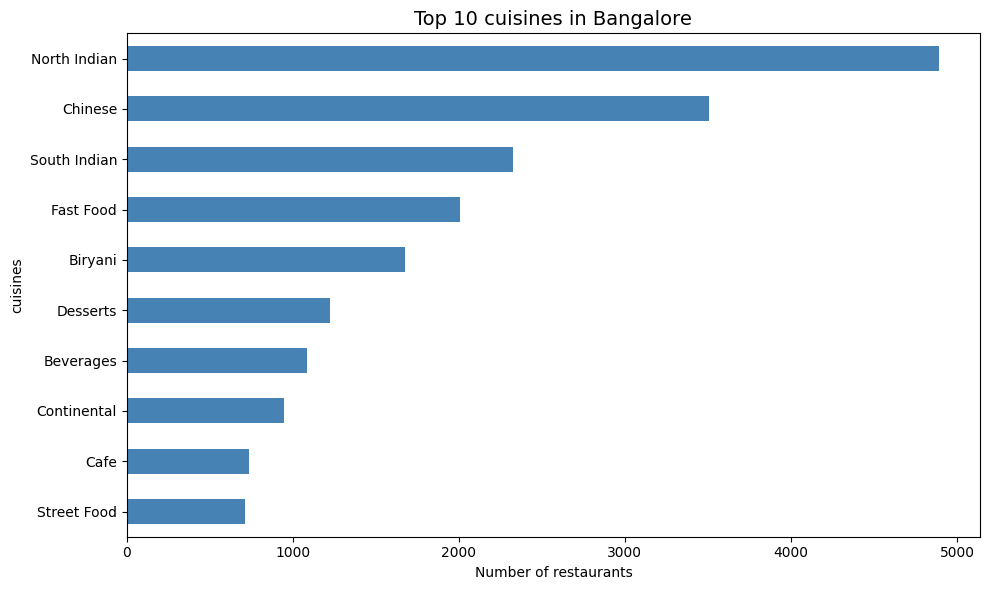

In [15]:
plt.figure(figsize = (10,6))
top_cuisine.plot(kind = 'barh', color = 'steelblue')
plt.title('Top 10 cuisines in Bangalore', fontsize = 14)
plt.xlabel('Number of restaurants')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

#### Most Popular Cuisines in Bangalore

The `cuisines` column contains multiple cuisines per restaurant in a single cell,
separated by commas. For example, one restaurant might have "North Indian, Chinese, Mughlai"
all in one cell.

If we count directly without splitting, we would count "North Indian, Chinese, Mughlai"
as one single cuisine instead of three separate ones, which would give us wrong results.
So we first split each cell at the comma, then explode so each cuisine gets its own row,
and then count individually.

This analysis tells us which cuisines are most commonly offered by restaurants in Bangalore,
which reflects the food demand and market preference of the city.

#### Observation

North Indian cuisine dominates Bangalore's restaurant scene with neayl5 3000 restaurants
offering it, followed closely by Chinese with arou3d 2800 restaurants.

This high supply of North Indian and Chinese food reflects strong and consistent demand
for these cuisines in the city. Both cuisines are widely accepted across different age
groups and income levels, which makes them the safest and most common choice for
restaurant owners.

From a business perspective, anyone planning to open a new restaurant in Bangalore
would face the highest competition in the North Indian and Chinese segment.
Cuisines like Biryani and Desserts appearing in the top 10 show emerging food trends
that have room for growth with less competition.

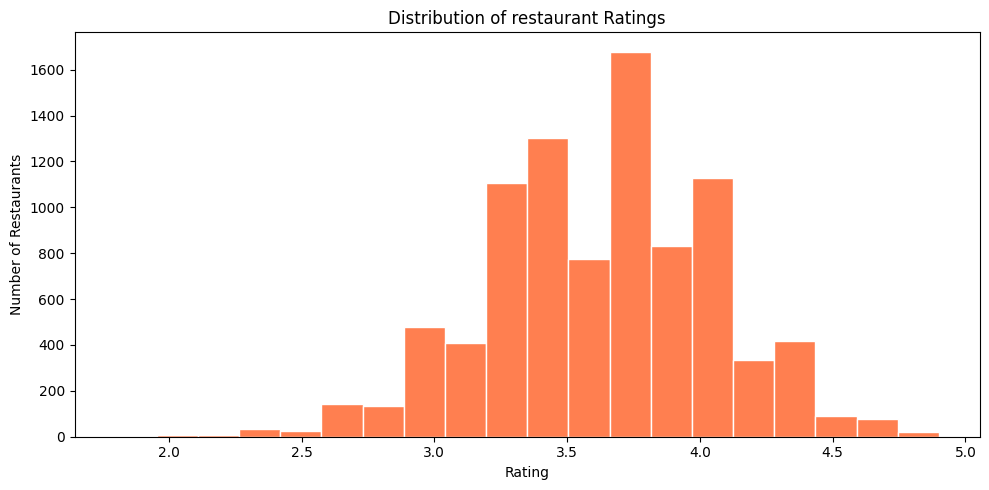

In [16]:
plt.figure(figsize=(10,5))
df_clean['rate'].dropna().plot(kind='hist', bins=20, edgecolor= 'white', color = 'coral')
plt.title("Distribution of restaurant Ratings")
plt.xlabel("Rating")
plt.ylabel("Number of Restaurants")
plt.tight_layout()
plt.show()

The rate columns contains the overall rating of each restaurant on the scale of 1 to 5.
This column has 7,775 missing values which belong to new or inactive restaurant that have not received any ratings yet. We drop these rows for this analysis because replacing them with the fake ratings like mean or median will hamper the analysis. 

the histogram is right chart her because ratings is continuous numbers, not categories. 

#### Observation

The majority of restaurants in Bangalore are clustered between ratings of 3.5 and 4.0,
with the peak around 3.8. This means most restaurants on Zomato offer a fairly
average to above average dining experience.

Around 1,600 restaurants have a rating of 4.0, making it the single most common
rating in the dataset. Very few restaurants fall below 3.0 or above 4.5,
which suggests that extremely poor and extremely exceptional restaurants
are rare in Bangalore.

Overall the rating distribution tells us that Zomato's Bangalore restaurant
scene is consistently average — there is little variation in quality,
and standing out with a high rating above 4.3 would make a restaurant
genuinely exceptional compared to its competition.

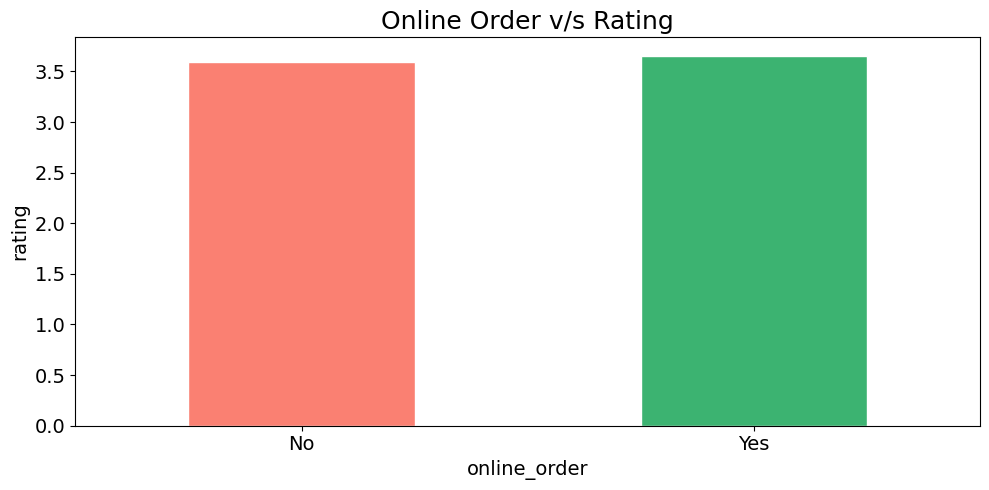

In [17]:
plt.figure(figsize=(10,5))
df_clean.groupby('online_order')['rate'].mean().plot(kind='bar', color=['salmon', 'mediumseagreen'], fontsize = 14, edgecolor = 'white')
plt.title('Online Order v/s Rating', fontsize = 18)
plt.xlabel('online_order', fontsize = 14)
plt.ylabel('rating',fontsize = 14)
plt.xticks(rotation = 0)
plt.tight_layout()
plt.show()

#### Observation
Restaurants that offers online ordering have an average rating of 3.8 while , restaurants that donot offer online ordering have an average rating of 3.5.

0.3 difference might be seem small but is significant in this scenario as the rating is on the scale of 1 to 5. Hence, 0.3 difference makes a huge difference. 

The resturants offering online ordering tend to have better reach to customers. 

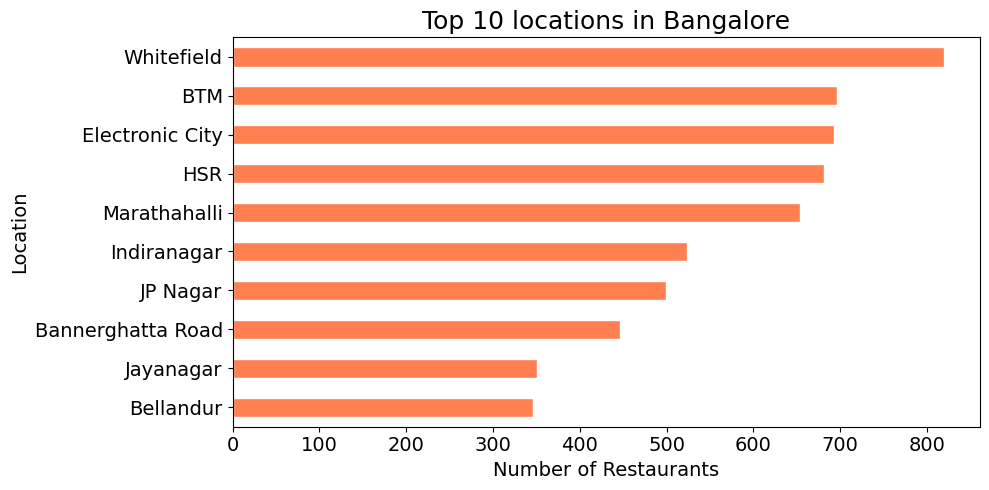

In [18]:
plt.figure(figsize=(10,5))
df_clean['location'].value_counts().head(10).plot(kind='barh', color='coral', edgecolor='white', fontsize = 14)
plt.title('Top 10 locations in Bangalore', fontsize = 18)
plt.xlabel('Number of Restaurants', fontsize = 14)
plt.ylabel('Location', fontsize = 14)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

#### Observation
The prime location of restaurant is whitefeild with 830 restaurants . For a individual to open a restaurant, this will be the most competing area. THis is followed by BTM. These are the areas having the highest number of restaurants, this implies these areas are having high footfall. These location are spread across Bangalore. For less competition, one should open restaurent in Bellandur or Jayanagar having less number of restaurent and also come in high active areas

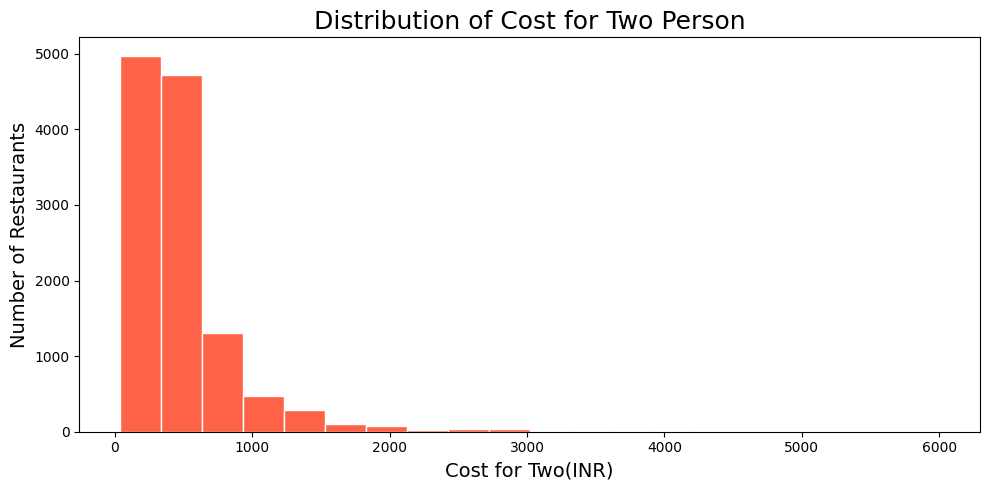

In [19]:
plt.figure(figsize=(10,5))
df_clean['cost_for_two'].dropna().plot(kind='hist', bins = 20, color = 'tomato', edgecolor = 'white')
plt.title("Distribution of Cost for Two Person", fontsize = 18)
plt.xlabel("Cost for Two(INR)", fontsize=14)
plt.ylabel("Number of Restaurants", fontsize=14)
plt.tight_layout()
plt.show()


#### Observation:
A new restaurant owner should consider pricing under 1000 because huge number of restaurants are having pricing under 1000 for two persons. 
This distribution graph is skewed towards budget and restaurants above 2000 is rare.

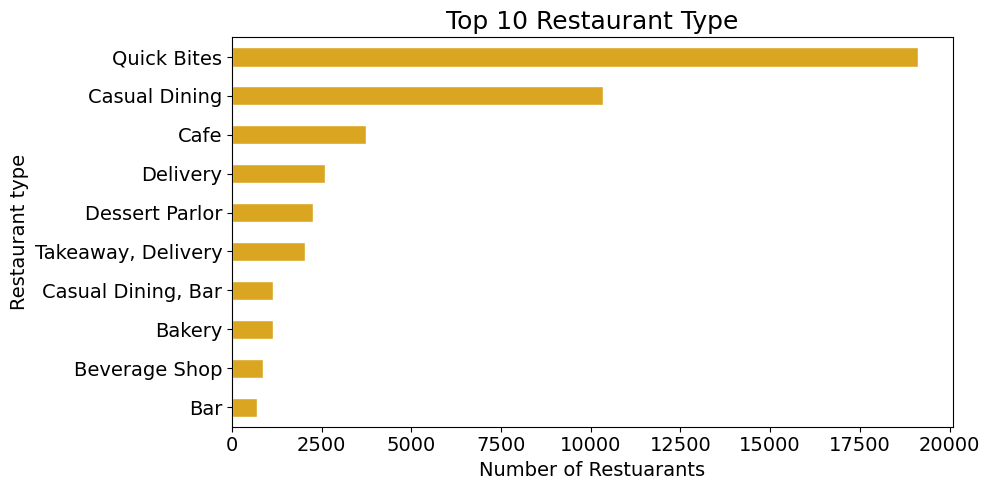

In [20]:
plt.figure(figsize = (10,5))
df_full['rest_type'].value_counts().head(10).plot(kind = 'barh', color = 'goldenrod', edgecolor = 'white', fontsize = 14)
plt.title("Top 10 Restaurant Type", fontsize = 18)
plt.xlabel("Number of Restuarants", fontsize = 14)
plt.ylabel("Restaurant type", fontsize = 14)
plt.tight_layout()
plt.gca().invert_yaxis()
plt.show()


#### Observation: 
The most common restaurant type is Quick bites in banagalore with 19000 restaurants. The reson might be as banaglore is an IT hub, people at evening are willing to have something, which why quick bites are dominating the market.

For new restaurants owner, they must offer quick bites along with casual dining as casual dining is the second highest restaurant type. This will help will to attract alrger audience

## Deeper Analysis

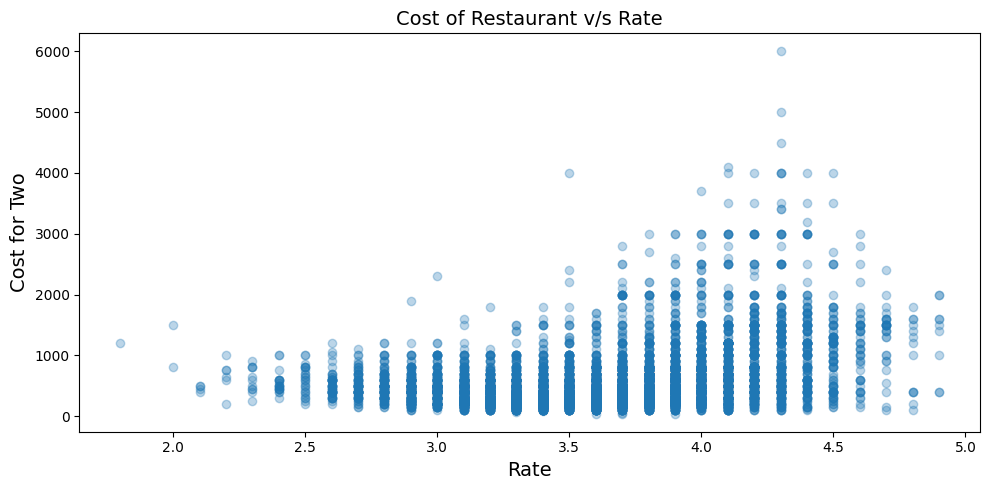

In [21]:
scatter_df = df_clean[['cost_for_two', 'rate']].dropna()
plt.figure(figsize=(10,5))
plt.scatter(scatter_df['rate'].dropna(), scatter_df['cost_for_two'].dropna(), alpha = 0.3)
plt.title('Cost of Restaurant v/s Rate', fontsize = 14)
plt.xlabel('Rate', fontsize = 14)
plt.ylabel('Cost for Two', fontsize = 14)
plt.tight_layout()
plt.show()

#### Observation: 
From the scatter plot, on increasing of rating, the cost slightly increase which shows weak positive correlation. Higher rated restaurants are wide spread, but there is rarely an expensive which has low rating. 
From bussiness point of view, Price alone cannot determine rating - a budget restaurant and a premium restaurant can both acheive high ratings. Quality of food and service matters more than pricing.

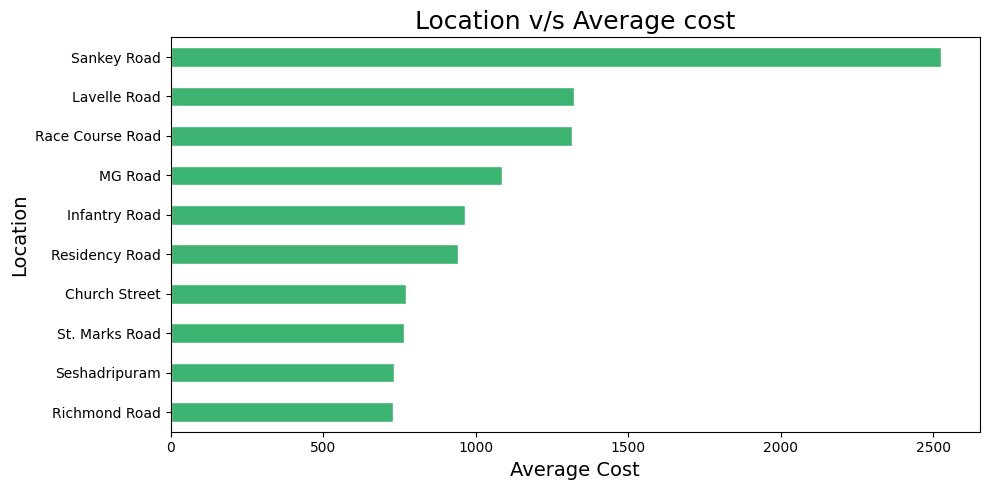

In [22]:
plt.figure(figsize = (10,5))
df_clean.groupby('location')['cost_for_two'].mean().sort_values(ascending = False).head(10).plot(kind = 'barh', color = 'mediumseagreen', edgecolor = 'white')
plt.title('Location v/s Average cost', fontsize = 18)
plt.xlabel('Average Cost', fontsize = 14)
plt.ylabel('Location', fontsize = 14)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

#### Observation:
The location having highest average cost is sankey road with 2500 as average cost followed by lavelle road. This is completely different from the high restaurant count location. These two data tells, location having high number of restaurants is not having high average cost. 

From bussiness point of view, having high number of restaurants in your desired location, does not mean, cost of your restaurant dishes to be high. The restaurants having low number of restaurants but, high average cost means, it's customers lilely to belong to posh area.

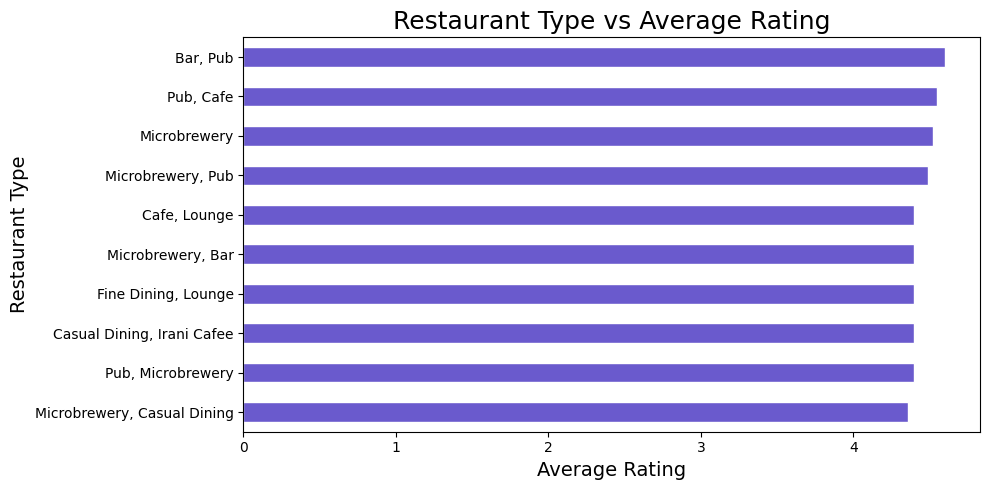

In [23]:
plt.figure(figsize = (10,5))
df_clean.groupby('rest_type')['rate'].mean().sort_values(ascending = False).head(10).plot(kind = 'barh', color = 'slateblue', edgecolor = 'white')
plt.title('Restaurant Type vs Average Rating', fontsize=18)
plt.xlabel('Average Rating', fontsize=14)
plt.ylabel('Restaurant Type', fontsize=14)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

#### Observation
From the graph, it is clear that bar, pub have the highest rating of 4.5 followed by pub and cafe. From the top 10 rated places, 9 are beer consuption and casual dinning places like pub, bar, microbrewery. Out of which top 3 are beer consumption places. Cafe and casual dining is at the 7th top rated restaurant. 

From a business point of view, a new owner should initally establish a restaurant in form of bar and later convert to microbrewery, because out of 10 , 5 are top rated for microbrewery.

Bangalore being a IT hub with high number of bachloers living might consume beer and along with quick bites like snacks are needed which due which bar, pub have high rating and quick bites have high number of restaurants.

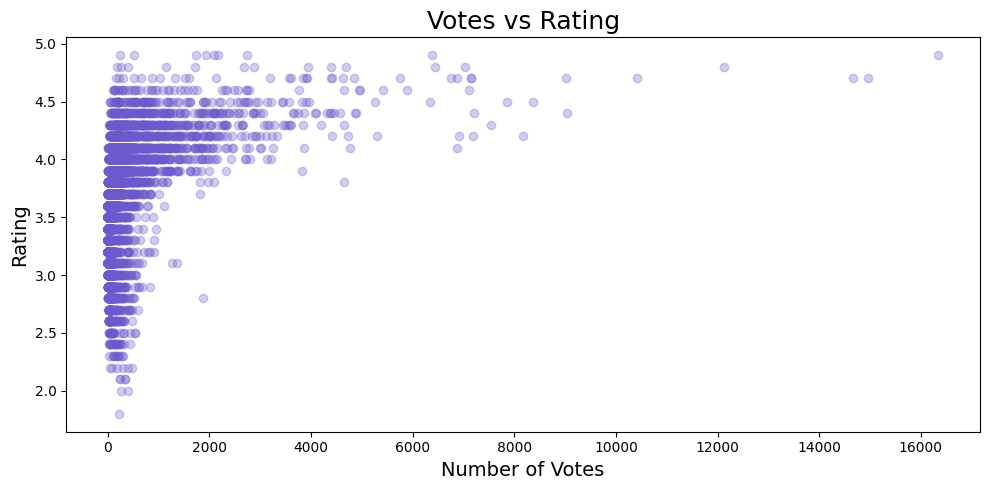

In [24]:
scatter_df = df_clean[['votes', 'rate']].dropna()
plt.figure(figsize=(10,5))
plt.scatter(scatter_df['votes'], scatter_df['rate'], alpha=0.3, color='slateblue')
plt.title('Votes vs Rating', fontsize=18)
plt.xlabel('Number of Votes', fontsize=14)
plt.ylabel('Rating', fontsize=14)
plt.tight_layout()
plt.show()

In [25]:
df_clean.to_csv('../data/zomato_clean.csv', index=False)
print("Clean dataset exported successfully!")
print(f"Shape: {df_clean.shape}")

Clean dataset exported successfully!
Shape: (12091, 17)


#### Observation
From the plot, it is clearly visible most of the restaurant are cluttered at low votes and as the number of votes increases the rating is above 4.0. The restaurants cluttered at low votes are spread evenly across 2.0 to 5 ratings. The restauratns with higher number of votes i.e above 4000, have rating greater than 4.0. This suggests higher the votes, higher the rating, but this true only when votes are greater than 2000.

## Final Summary - Key Insights
This analysis of 12,091 unique restaurants across Bangalore revealed the following key findings:

### Cuisine Trends
1. North Indian and Chinese Cuisine dominates the market with nearly 3000 restuarants each, and biryani have a scope to grow and have less competition.

### Ratings
2. Most of the restaurant have rating in range of 3.5 to 4.0 with a peak rating of 3.8. Restaurants offer average to above average experience.

### Online Ordering
3. Restaurants that offers online ordering have an average rating of 3.8 while , restaurants that donot offer online ordering have an average rating of 3.5. This suggests online ordering is associated with better overall restaurant performance.

### Location
4. Whitefield is the prime location and most competing location for restaurants owners. Bellandur and Jayanagar have fewer restaurants but high footfall, making them better options for new owners for set up.

### Pricing
5. Most of the Restaurant have pricing under 1000 for two persons, which shows a budget friendly dining market.

### Restaurant Types
6. Quick Bites and casual dining together acquire most of the restaurants and for a new restaurant owner, he or she should focus on these two categories to attract larger audience.

### Business Strategy for New Restaurant Owners
7. Quick bites along with bar kind of restaurant which can be later turned into a microbrewery can lead to attract large number of customers.

### Conclusion
Bangalore's restaurant market is dominated by budget-friendly, quick service outlets which is driven by the large IT sector. However, microbreweries and fine dining represent new opportunities with less competition and higher customer satisfaction.